# diy dataset

source url: https://raw.githubusercontent.com/leonism/sample-superstore/master/data/superstore.csv

this notebook uses a 3500 row sample from the public superstore csv so the final zip stays small.

## load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

source_url = "https://raw.githubusercontent.com/leonism/sample-superstore/master/data/superstore.csv"

try:
    raw = pd.read_csv(source_url)
except:
    raw = pd.read_csv("superstore.csv")

df = raw.sample(n=3500, random_state=42).sort_values("Row ID").reset_index(drop=True)
df.head()

Matplotlib is building the font cache; this may take a moment.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2.0,0.0,41.9136
1,100,CA-2017-158568,8/29/2017,9/2/2017,Standard Class,RB-19465,Rick Bensley,Home Office,United States,Chicago,Illinois,60610.0,Central,OFF-PA-10003256,Office Supplies,Paper,Avery Personal Creations Heavyweight Cards,64.624,7.0,0.2,22.6184
2,1003,CA-2016-124891,7/31/2016,7/31/2016,Same Day,RH-19495,Rick Hansen,Consumer,United States,New York City,New York,10024.0,East,FUR-TA-10002903,Furniture,Tables,"Bevis Round Bullnose 29"" High Table Top",1090.782,7.0,0.4,-290.8752
3,1006,CA-2016-111199,11/13/2016,11/17/2016,Standard Class,JK-15730,Joe Kamberova,Consumer,United States,Jacksonville,North Carolina,28540.0,South,OFF-PA-10001790,Office Supplies,Paper,Xerox 1910,115.296,3.0,0.2,40.3536
4,1010,CA-2018-135034,8/1/2018,8/3/2018,First Class,AT-10735,Annie Thurman,Consumer,United States,Chicago,Illinois,60653.0,Central,TEC-PH-10003931,Technology,Phones,JBL Micro Wireless Portable Bluetooth Speaker,95.984,2.0,0.2,5.9990


## preprocessing task 1: handle missing values

In [2]:
def fill_postal_codes(data):
    out = data.copy()
    before = out[out["Postal Code"].isna()][["City", "State", "Postal Code"]].copy()
    before["row_number"] = before.index

    city_state_fill = (
        out.dropna(subset=["Postal Code"])
        .groupby(["City", "State"])["Postal Code"]
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
    )

    state_fill = (
        out.dropna(subset=["Postal Code"])
        .groupby("State")["Postal Code"]
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
    )

    overall_fill = int(out["Postal Code"].dropna().median())

    def get_code(row):
        if pd.notna(row["Postal Code"]):
            return int(row["Postal Code"])
        key = (row["City"], row["State"])
        if key in city_state_fill.index:
            return int(city_state_fill.loc[key])
        if row["State"] in state_fill.index:
            return int(state_fill.loc[row["State"]])
        return overall_fill

    out["Postal Code"] = out.apply(get_code, axis=1).astype("int64")
    after = out.loc[before.index, ["City", "State", "Postal Code"]].copy()
    after["row_number"] = after.index
    changed = before.merge(after, on="row_number", suffixes=("_before", "_after"))
    return out, changed

df, missing_changed = fill_postal_codes(df)
missing_changed.head(10)

,City_before,State_before,Postal Code_before,row_number,City_after,State_after,Postal Code_after
0,Burlington,Vermont,NaN,1552,Burlington,Vermont,58103
1,Burlington,Vermont,NaN,2927,Burlington,Vermont,58103
2,Burlington,Vermont,NaN,3026,Burlington,Vermont,58103
3,Burlington,Vermont,NaN,3027,Burlington,Vermont,58103
4,NaN,NaN,NaN,3243,NaN,NaN,58103
5,NaN,NaN,NaN,3244,NaN,NaN,58103
6,NaN,NaN,NaN,3245,NaN,NaN,58103
7,NaN,NaN,NaN,3246,NaN,NaN,58103
8,NaN,NaN,NaN,3247,NaN,NaN,58103
9,NaN,NaN,NaN,3248,NaN,NaN,58103


## preprocessing task 2: remove duplicates from the dataset

In [3]:
def remove_dupes(data):
    out = data.copy()
    dupes = out[out.duplicated(keep="first")].copy()
    dupes["row_number"] = dupes.index
    out = out.drop_duplicates().reset_index(drop=True)
    return out, dupes

df, dupes_changed = remove_dupes(df)
dupes_changed.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,row_number
3276,Yes,US-2015-140452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3276
3279,Yes,US-2015-164763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3279
3283,Yes,US-2018-103828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3283
3285,Yes,US-2018-118087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3285
3289,Yes,CA-2017-134803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3289
3299,Yes,CA-2017-145982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3299
3310,Yes,CA-2016-146262,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3310
3311,Yes,CA-2015-141726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3311
3319,Yes,CA-2018-124401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3319
3322,Yes,CA-2017-157280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3322


## preprocessing task 3: handle outliers

In [4]:
def cap_sales_outliers(data):
    out = data.copy()
    q1 = out["Sales"].quantile(0.25)
    q3 = out["Sales"].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    mask = (out["Sales"] < low) | (out["Sales"] > high)
    changed = out.loc[mask, ["Sales", "Profit", "Category"]].copy()
    changed["row_number"] = changed.index
    changed["Sales_after"] = out.loc[mask, "Sales"].clip(lower=low, upper=high).values

    out["Sales"] = out["Sales"].clip(lower=low, upper=high)
    return out, changed, low, high

df, outlier_changed, low_cut, high_cut = cap_sales_outliers(df)
outlier_changed.head(10)

,Sales,Profit,Category,row_number,Sales_after
2,1090.782,-290.8752,Furniture,2,508.33
10,1379.920,648.5624,Technology,10,508.33
21,1363.960,85.2475,Technology,21,508.33
34,836.592,-264.9208,Furniture,34,508.33
42,1706.184,85.3092,Furniture,42,508.33
53,619.950,111.5910,Technology,53,508.33
55,699.930,181.9818,Technology,55,508.33
57,1067.940,224.2674,Furniture,57,508.33
62,686.320,223.0540,Technology,62,508.33
64,644.076,107.3460,Office Supplies,64,508.33


In [5]:
df.loc[outlier_changed["row_number"].head(10), ["Order ID", "Category", "Sales", "Profit"]]

,Order ID,Category,Sales,Profit
2,CA-2016-124891,Furniture,508.33,-290.8752
10,CA-2016-124450,Technology,508.33,648.5624
21,CA-2017-169103,Technology,508.33,85.2475
34,US-2017-143819,Furniture,508.33,-264.9208
42,CA-2015-115812,Furniture,508.33,85.3092
53,CA-2016-142755,Technology,508.33,111.5910
55,US-2015-147627,Technology,508.33,181.9818
57,US-2015-147627,Furniture,508.33,224.2674
62,CA-2015-146969,Technology,508.33,223.0540
64,CA-2016-112452,Office Supplies,508.33,107.3460


## preprocessing task 4: uniform case standardization for text

In [6]:
def clean_text_case(data, cols):
    out = data.copy()
    for col in cols:
        out[col] = out[col].astype(str).str.strip().str.lower()
    return out

text_demo = pd.DataFrame(
    {
        "ship mode": [" first class ", "SECOND CLASS", "standard class", "Same Day ", " second class "],
        "region": [" east", "WEST ", "central", " South ", "EAST  "],
    }
)

text_after = clean_text_case(text_demo, ["ship mode", "region"])
text_changed = text_demo.copy()
text_changed["row_number"] = text_changed.index
text_changed["ship mode_after"] = text_after["ship mode"]
text_changed["region_after"] = text_after["region"]
text_changed

,ship mode,region,row_number,ship mode_after,region_after
0,first class,east,0,first class,east
1,SECOND CLASS,WEST,1,second class,west
2,standard class,central,2,standard class,central
3,Same Day,South,3,same day,south
4,second class,EAST,4,second class,east


## preprocessing task 5: normalize mixed format dates to yyyy-mm-dd

In [7]:
def normalize_dates(data, cols):
    out = data.copy()
    for col in cols:
        out[col] = pd.to_datetime(out[col], errors="coerce").dt.strftime("%Y-%m-%d")
    return out

df = normalize_dates(df, ["Order Date", "Ship Date"])
df[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-08-29,2017-09-02
2,2016-07-31,2016-07-31
3,2016-11-13,2016-11-17
4,2018-08-01,2018-08-03
5,2015-11-24,2015-11-26
6,2016-07-06,2016-07-10
7,2016-07-06,2016-07-10
8,2017-08-29,2017-09-02
9,2016-04-27,2016-05-03


## small sample after the last 3 cleaning steps

In [8]:
print("outlier sample")
display(df[["Order ID", "Sales", "Profit"]].head(10))

print("text standardization sample")
display(text_after.head())

print("date sample")
display(df[["Order Date", "Ship Date"]].head(10))

outlier sample


,Order ID,Sales,Profit
0,CA-2017-152156,261.960,41.9136
1,CA-2017-158568,64.624,22.6184
2,CA-2016-124891,508.330,-290.8752
3,CA-2016-111199,115.296,40.3536
4,CA-2018-135034,95.984,5.9990
5,CA-2015-158540,151.720,27.3096
6,CA-2016-108665,155.820,63.8862
7,CA-2016-108665,124.950,2.4990
8,CA-2017-158568,1.788,-3.0396
9,CA-2016-124450,22.740,8.8686


text standardization sample


,ship mode,region
0,first class,east
1,second class,west
2,standard class,central
3,same day,south
4,second class,east


date sample


,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-08-29,2017-09-02
2,2016-07-31,2016-07-31
3,2016-11-13,2016-11-17
4,2018-08-01,2018-08-03
5,2015-11-24,2015-11-26
6,2016-07-06,2016-07-10
7,2016-07-06,2016-07-10
8,2017-08-29,2017-09-02
9,2016-04-27,2016-05-03


## save cleaned dataset

In [9]:
df.to_csv("diy_dataset.csv", index=False)
df.shape

(3417, 21)

## preprocessing markdown explanation

issues present in my dataset:
- missing postal code values were present. i filled them with a city and state based code, then a state based code, then a final fallback.
- duplicate rows were present. i removed exact duplicates.
- sales outliers were present. i capped them with the iqr rule.
- the date columns were not in yyyy-mm-dd format. i changed order date and ship date to that format.

issues not present in my dataset:
- mixed text case and extra spaces were not a clear problem in the sampled data, so i made a small example table and showed the function on that example.

## analysis task 1: top n within each group

In [10]:
top_n = (
    df.groupby(["Region", "Sub-Category"], as_index=False)["Sales"]
    .sum()
    .sort_values(["Region", "Sales", "Sub-Category"], ascending=[True, False, True])
)

top_3_each_region = top_n.groupby("Region").head(3).reset_index(drop=True)
top_3_each_region

,Region,Sub-Category,Sales
0,Central,Chairs,21205.176
1,Central,Phones,16509.362
2,Central,Storage,12086.554
3,East,Phones,22198.328
4,East,Chairs,18438.018
5,East,Storage,15292.030
6,South,Phones,14341.428
7,South,Chairs,10167.584
8,South,Accessories,7494.420
9,West,Chairs,22060.140


## analysis task 2: bin comparison

In [11]:
bins = [0, 2, 5, 8, 14]
labels = ["1-2", "3-5", "6-8", "9-14"]
df["quantity_bin"] = pd.cut(df["Quantity"], bins=bins, labels=labels, include_lowest=True)

bin_compare = df.groupby("quantity_bin", observed=False)["Profit"].mean().reset_index()
bin_compare

,quantity_bin,Profit
0,1-2,18.327071
1,3-5,27.737165
2,6-8,42.101813
3,9-14,103.104665


## analysis task 3: conditional aggregation

In [12]:
df["order_year"] = pd.to_datetime(df["Order Date"]).dt.year

sales_2018 = (
    df[df["order_year"] == 2018]
    .groupby("Category", as_index=False)["Sales"]
    .mean()
    .sort_values("Sales", ascending=False)
)

sales_2018

,Category,Sales
0,Furniture,233.402404
2,Technology,213.361857
1,Office Supplies,89.310492


## analysis task 4: change over time

In [13]:
df["order_month"] = pd.to_datetime(df["Order Date"]).dt.to_period("M").astype(str)

month_avg_sales = (
    df.groupby("order_month", as_index=False)["Sales"]
    .mean()
    .sort_values("order_month")
)

month_avg_sales.head(12)

,order_month,Sales
0,2015-01,147.582957
1,2015-02,83.444889
2,2015-03,158.264528
3,2015-04,154.999561
4,2015-05,144.525185
5,2015-06,174.886788
6,2015-07,162.420852
7,2015-08,98.452837
8,2015-09,163.889606
9,2015-10,141.615449


## visualization 1: scatter plot

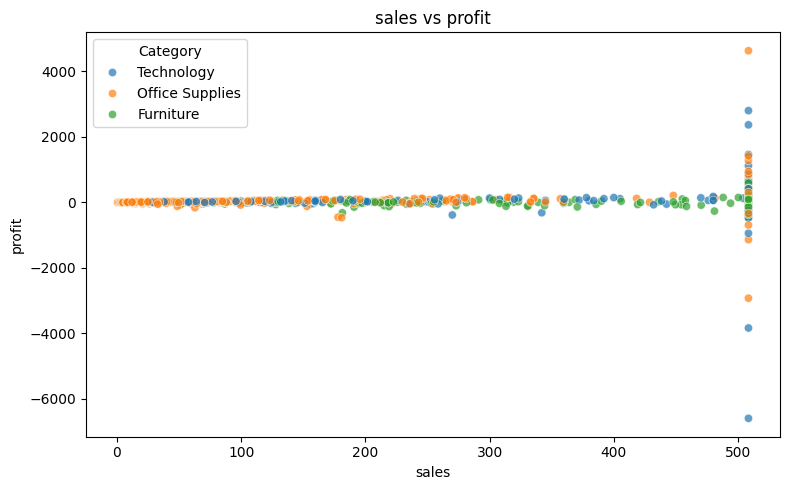

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(min(1200, len(df)), random_state=42), x="Sales", y="Profit", hue="Category", alpha=0.7)
plt.title("sales vs profit")
plt.xlabel("sales")
plt.ylabel("profit")
plt.tight_layout()
plt.show()

main takeaway: sales and profit usually move together, but some high sales orders still lose money.

## visualization 2: line chart

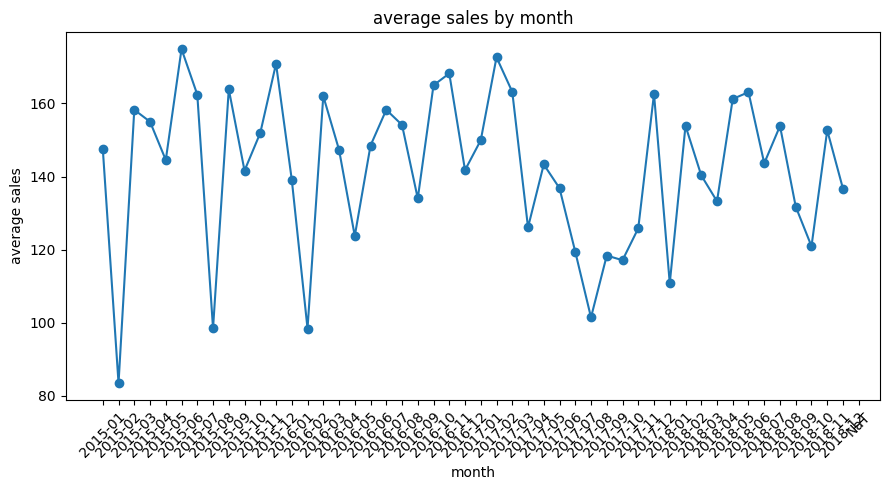

In [15]:
month_line = month_avg_sales.copy()

plt.figure(figsize=(9, 5))
plt.plot(month_line["order_month"], month_line["Sales"], marker="o")
plt.title("average sales by month")
plt.xlabel("month")
plt.ylabel("average sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

main takeaway: average sales change a lot from month to month instead of staying flat.

## visualization 3: box plot

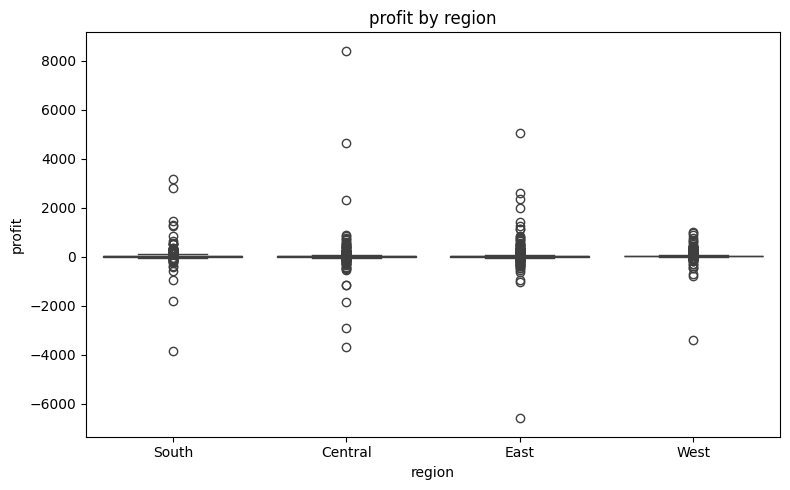

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Region", y="Profit")
plt.title("profit by region")
plt.xlabel("region")
plt.ylabel("profit")
plt.tight_layout()
plt.show()

main takeaway: profit spread is different by region, and each region has some extreme values.

## visualization 4: histogram

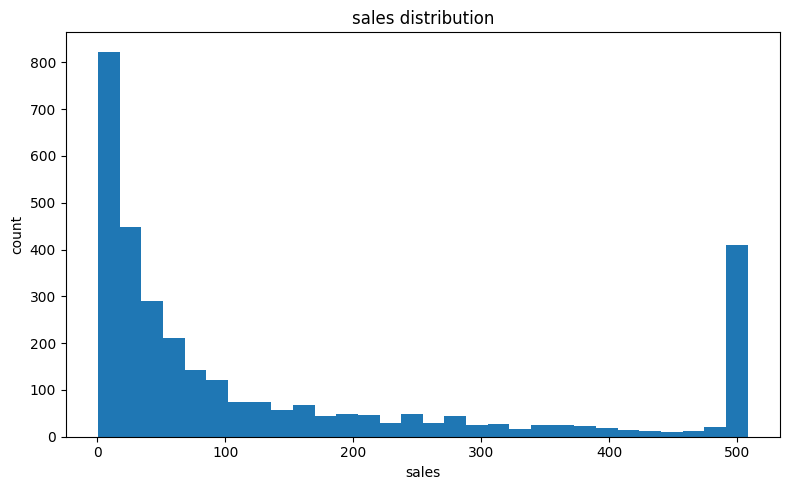

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df["Sales"], bins=30)
plt.title("sales distribution")
plt.xlabel("sales")
plt.ylabel("count")
plt.tight_layout()
plt.show()

main takeaway: most orders are small, and only a small number of orders have very large sales.

## visualization 5: pie chart

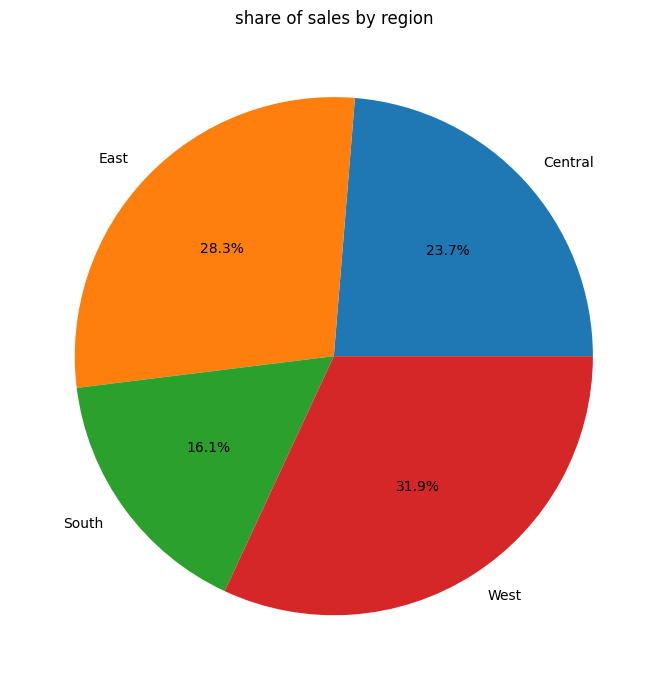

In [18]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(7, 7))
plt.pie(region_sales, labels=region_sales.index, autopct="%1.1f%%")
plt.title("share of sales by region")
plt.tight_layout()
plt.show()

main takeaway: total sales are split across regions, but some regions take a bigger share than others.